In [ ]:
from statsmodels.tsa.api import VAR
import numpy as np
import pandas as pd
import torch

def run_var_baseline(train_data, test_data, lags=1):
    # train_data: (Time, Features) for the training period
    # 1. Fit the model on 'normal' training data
    model = VAR(train_data)
    results = model.fit(lags)
    
    # 2. Get residuals on the test data
    # We use the fitted coefficients to 'forecast' 1 step ahead for each day
    # and compare it to the actual observed features
    predictions = []
    for i in range(lags, len(test_data)):
        # Predict next step based on 'lags' previous steps
        prev_data = test_data[i-lags:i]
        pred = results.forecast(prev_data, steps=1)
        predictions.append(pred[0])
        
    # 3. Calculate Anomaly Signal (Mean Squared Error per day)
    actuals = test_data[lags:]
    residuals = np.abs(actuals - np.array(predictions))
    
    # The anomaly score is the mean residual across all 11 features
    anomaly_signal = residuals.mean(axis=1) 
    return anomaly_signal #(time, )

In [2]:
print("\n[1/6] Loading data...")
device = torch.device("cpu")

# Load prices
prices = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
prices.dropna(how='all', inplace=True)
prices = prices.ffill().bfill()
prices.columns = prices.columns.droplevel(1)

all_stocks = prices.columns.tolist()
stock2idx = {s: i for i, s in enumerate(all_stocks)}
idx2stock = {i: s for s, i in stock2idx.items()}
N_full = len(all_stocks)

# Load sectors
sectors = pd.read_excel('SPX_sectors_data.xlsx', sheet_name='Sectors', 
                        header=0, index_col=0)
sectors['sector_id'] = sectors['Sector'].astype('category').cat.codes


tickers = prices.columns.get_level_values(0).unique().tolist()
node_map = {ticker: i for i, ticker in enumerate(tickers)}

# Split data: Train 2007-2009, Test 2019-2021
train_prices = prices.loc['2012-01-01':'2016-12-31']
test_prices = prices.loc['2019-07-01':'2024-12-31']
val_prices = prices.loc["2017-01-01":"2019-06-30"]

returns = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
returns.columns = returns.columns.get_level_values(0)
returns.dropna(how='all', inplace=True) 
returns = returns.pct_change().dropna(how='all')
#returns = returns.ffill().bfill()
# Compute returns
# train_returns = train_prices.pct_change().dropna(how='all')
# test_returns = test_prices.pct_change().dropna(how='all')
train_returns = returns.loc['2012-01-01':'2016-12-31']
train_returns = train_returns.ffill().bfill()
test_returns = returns.loc['2019-07-01':'2024-12-31']
test_returns = test_returns.ffill().bfill()
val_returns = returns.loc["2017-01-01":"2019-06-30"]
val_dates = val_returns.index
all_dates = sorted(set(train_returns.index) | set(test_returns.index) | set(val_returns.index))
test_dates = test_returns.index
# Compute volatility
train_volatility = train_returns.rolling(window=21).std().dropna(how='all') * np.sqrt(252)
test_volatility = test_returns.rolling(window=21).std().dropna(how='all') * np.sqrt(252)
volatility = pd.concat([train_volatility, test_volatility]).sort_index()

# Helper to load and fix dates
def load_and_fix_index(filename):
    df = pd.read_csv(filename, index_col=0)
    df.index = pd.to_datetime(df.index, format='%m/%d/%Y') # Fix date format
    df.dropna(how='all', inplace=True)
    df = df.ffill().bfill()
    return df

# Load Constituent Factors (Tables where Cols = Tickers, Rows = Dates)
Market_caps = load_and_fix_index('Data/SPX_Constituents_market_cap_2006_2025(in).csv')

PE_ratios = load_and_fix_index('Data/SPX_Constituents_Calculated_PE_2006_2025(in).csv')

Implied_vol = load_and_fix_index('Data/SPX_Constituents_Implied_vol_2006_2025(in).csv')

Beta = load_and_fix_index('Data/SPX_Constituents_Beta_2006_2025(in).csv')
Operating_margin = load_and_fix_index('Data/SPX_Constituents_Op_Margin_2006_2025(in).csv')   
Return_on_equity = load_and_fix_index('Data/SPX_Constituents_Ret_On_Equity_2006_2025(in).csv')
RSI_momentum = load_and_fix_index('Data/SPX_Constituents_RSI_momentum_2006_2025(in).csv')
Short_interest = load_and_fix_index('Data/SPX_Constituents_Short_Interest_Pct_2006_2025(in).csv')
Turnover = load_and_fix_index('Data/SPX_Constituents_Turnover_30D_2006_2025(in).csv')


[1/6] Loading data...


C:\Users\archi\AppData\Local\Temp\ipykernel_38852\1677540423.py:32: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = returns.pct_change().dropna(how='all')


In [3]:
print('Precomputing Z scores for all features...')

def precompute_zscores(df, window=63):
    """Calculates rolling z-scores for an entire dataframe at once."""
    rolling_mean = df.rolling(window=window, min_periods=5).mean()
    rolling_std = df.rolling(window=window, min_periods=5).std()
    # Avoid division by zero with 1e-8
    z_scores = (df - rolling_mean) / (rolling_std + 1e-8)
    # Clip outliers to keep gradients stable and fill NaNs
    return z_scores.clip(-5.0, 5.0).fillna(0.0)

# Precompute z-scores for all feature dataframes
Z_DATA = {
    'volatility':       precompute_zscores(volatility), # use your vol_window here
    'market_caps':      precompute_zscores(Market_caps),
    'pe_ratios':        precompute_zscores(PE_ratios),
    'implied_vol':      precompute_zscores(Implied_vol),
    'short_interest':   precompute_zscores(Short_interest),
    'beta':             precompute_zscores(Beta),
    'op_margin':        precompute_zscores(Operating_margin),
    'roe':              precompute_zscores(Return_on_equity),
    'rsi':              precompute_zscores(RSI_momentum),
    'turnover':         precompute_zscores(Turnover)
}

Precomputing Z scores for all features...


In [6]:

def prepare_time_features(stock, sectors, Z_DATA, dates, norm_window=63): # 1 quarter
    """
    Normalise each feature per stock against its own rolling history (z-score),
    preserving signal relative to that stock's recent behaviour.
    """
    rows = []
    # i want (time x features) for this stock
    for t in dates:
        
        sector_id = sectors.loc[stock, 'sector_id'] if stock in sectors.index else 0
        
        # Simple lookup
        feats = []
        for key in Z_DATA:
            df = Z_DATA[key]
            val = df.loc[t, stock] if stock in df.columns and t in df.index else 0.0
            feats.append(float(val))
            
        rows.append(feats)

    features = np.array(rows, dtype=np.float32)
    return features


def get_active_stocks(returns, t, lookback_days, feature_dfs=None, min_obs=21, eps=0.0):
    t = pd.to_datetime(t)
    window = returns.loc[t - pd.Timedelta(days=lookback_days): t]
    #print(f"Window for active stock selection: {window.index.min().date()} to {window.index.max().date()}")
    # enough non-NaN observations
    counts = window.notna().sum(axis=0)
    ok_obs = counts >= min_obs

    # not constant zero in the window (treat as missing asset)
    if eps == 0.0:
        ok_nonzero = ~(window.fillna(0.0) == 0.0).all(axis=0)
    else:
        ok_nonzero = ~(window.fillna(0.0).abs() <= eps).all(axis=0)

    #active = window.columns[ok_obs & ok_nonzero].tolist()
    active = window.columns[ok_nonzero].tolist()
    #print(f"Active stocks before feature intersection: {len(active)}")
    if feature_dfs is not None:
        active_set = set(active)
        for df in feature_dfs:
            # only care if the stock exists as a column in the dataframe
            if not df.empty:
                # Find intersection between current active stocks and this dataframe's columns
                active_set = active_set.intersection(df.columns)
        
        active = list(active_set)

    return active

In [7]:
results = {} # stock: signals for each time step 
for stock in all_stocks:
    x_train = prepare_time_features(stock, sectors, Z_DATA, train_returns.index)
    x_test = prepare_time_features(stock, sectors, Z_DATA, test_returns.index)
    signals = run_var_baseline(x_train, x_test)
    results[stock] = signals

print(results)

{'A UN Equity': array([0.1127324 , 0.2227557 , 0.18162912, ..., 0.2249026 , 0.36724492,
       0.36261901]), 'AAPL UW Equity': array([0.18632149, 0.1616509 , 0.09527903, ..., 0.26068685, 1.19399263,
       0.12576093]), 'ABBV UN Equity': array([0.08652536, 0.16226775, 0.38904862, ..., 0.18053642, 0.1878807 ,
       1.17405145]), 'ABNB UW Equity': array([0.4436501 , 0.38099701, 0.30576472, ..., 0.58549128, 0.72857367,
       2.00791973]), 'ABT UN Equity': array([0.21814956, 0.2595358 , 0.19557182, ..., 0.17543377, 0.57557293,
       1.69670571]), 'ACGL UW Equity': array([0.15001752, 0.23857859, 0.19860256, ..., 0.25505287, 0.25878768,
       1.67091679]), 'ACN UN Equity': array([0.27320469, 0.33588424, 0.1508808 , ..., 0.23074687, 0.26038095,
       0.35188605]), 'ADBE UW Equity': array([0.1220746 , 0.19208814, 0.17426836, ..., 0.1636407 , 0.18756788,
       0.51979335]), 'ADI UW Equity': array([0.21610859, 0.09902145, 0.12379   , ..., 0.21601715, 0.40108352,
       0.41699343]), 'ADM U

In [10]:
from sklearn.metrics import roc_auc_score

def evaluate_once(test_results, prices, forward_window, crash_threshold):
    """
    test_results: Dict[stock_name, array_of_signals]
    prices: DataFrame with DatetimeIndex (rows) and stock names (cols)
    """
    y_true = []
    y_scores = []

    # 1. Identify valid evaluation dates (those with enough future data)
    last_possible_date = prices.index[-1] - pd.Timedelta(days=forward_window)
    # We only evaluate dates where we actually have a signal in test_results
    # Assuming all signal arrays in test_results match the prices.index length
    valid_dates = prices.index[prices.index <= last_possible_date]

    for stock, signals in test_results.items():
        if stock not in prices.columns:
            continue

        # Convert torch to numpy if necessary
        if isinstance(signals, torch.Tensor):
            signals = signals.cpu().numpy()
        
        signals = signals.flatten()
        
        # 2. Align signals with price index
        # This assumes signals[i] corresponds to prices.index[i]
        for i, t in enumerate(valid_dates):
            if i >= len(signals):
                break
            
            current_signal = signals[i]
            
            # Skip if signal is NaN
            if np.isnan(current_signal):
                continue

            # 3. Calculate forward returns
            p_t = prices.loc[t, stock]
            
            # Find the closest price date in the future
            future_target = t + pd.Timedelta(days=forward_window)
            future_idx = prices.index.searchsorted(future_target)

            if future_idx >= len(prices):
                continue

            p_future = prices.iloc[future_idx][stock]

            # Handle potential missing price data (NaNs in price DF)
            if np.isnan(p_t) or np.isnan(p_future) or p_t == 0:
                continue

            fwd_return = (p_future - p_t) / p_t
            crash = 1 if fwd_return < crash_threshold else 0

            y_true.append(crash)
            y_scores.append(current_signal)

    if len(y_true) == 0:
        return None

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)

    # 4. Metrics calculation
    try:
        auc = roc_auc_score(y_true, y_scores)
    except ValueError:
        # Occurs if only one class is present in y_true
        auc = 0.5

    baseline = y_true.mean()
    
    # Calculate Precision @ Top 10%
    if len(y_scores) >= 10:
        threshold_90 = np.percentile(y_scores, 90)
        top_decile_mask = y_scores >= threshold_90
        precision = y_true[top_decile_mask].mean()
        lift = precision / baseline if baseline > 0 else 1.0
    else:
        lift = 1.0

    return auc, lift, baseline

def grid_search(
        test_results,
        prices,
        forward_windows,
        crash_thresholds
):

    rows = []

    for fw in forward_windows:

        for ct in crash_thresholds:

            result = evaluate_once(
                test_results,
                prices,
                fw,
                ct
            )

            if result is None:
                continue

            auc, lift, baseline = result

            rows.append({

                "ForwardWindow": fw,

                "CrashThreshold": ct,

                "AUC": auc,

                "Lift": lift,

                "Baseline": baseline

            })

            print(
                f"FW={fw:3d} "
                f"CT={ct:6.2f} "
                f"AUC={auc:.3f} "
                f"Lift={lift:.2f}"
            )

    return pd.DataFrame(rows)

In [11]:
forward_windows = [10,22,44]

crash_thresholds = [-0.10,-0.15,-0.20,-0.30]

df_results = grid_search(

    results,

    test_prices,

    forward_windows,

    crash_thresholds

)

# for test_results_test : FW=  5 CT= -0.30 AUC=0.785 Lift=4.45 testing from 2020-2024


FW= 10 CT= -0.10 AUC=0.640 Lift=2.08
FW= 10 CT= -0.15 AUC=0.709 Lift=2.64
FW= 10 CT= -0.20 AUC=0.748 Lift=2.81
FW= 10 CT= -0.30 AUC=0.762 Lift=2.89
FW= 22 CT= -0.10 AUC=0.583 Lift=1.58
FW= 22 CT= -0.15 AUC=0.629 Lift=2.02
FW= 22 CT= -0.20 AUC=0.674 Lift=2.45
FW= 22 CT= -0.30 AUC=0.716 Lift=2.80
FW= 44 CT= -0.10 AUC=0.554 Lift=1.35
FW= 44 CT= -0.15 AUC=0.578 Lift=1.59
FW= 44 CT= -0.20 AUC=0.603 Lift=1.83
FW= 44 CT= -0.30 AUC=0.622 Lift=2.01


Visualizing Average Anomaly Signal...


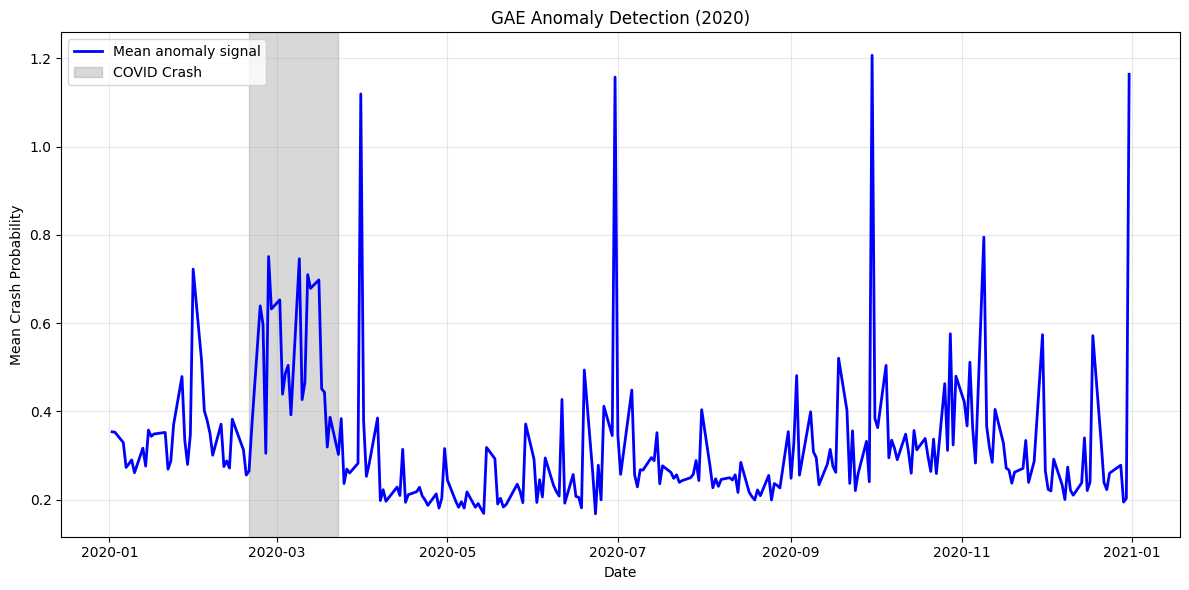

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Visualizing Average Anomaly Signal...")

# 1. Convert the dictionary results into a DataFrame
# Structure: results = { 'STOCK_A': [sig1, sig2, ...], 'STOCK_B': [sig1, sig2, ...] }
# This assumes all signal lists are the same length and correspond to the same timeline.
df_signals = pd.DataFrame(results)

# 2. Assign the dates to the index
# Note: You'll need your list of dates here. Replace 'trading_dates' with your date list.
# If your signal lists already correspond to specific dates:
df_signals.index = pd.to_datetime(test_dates[1:]) 

# 3. Calculate the mean signal across all stocks for each date
avg_signals = df_signals.mean(axis=1).sort_index()

# 4. Filter for 2020
try:
    avg_signals_2020 = avg_signals.loc['2020-01-01':'2020-12-31']
except KeyError:
    print("Warning: Date range not found in data.")
    avg_signals_2020 = pd.Series()

# 5. Plot
if not avg_signals_2020.empty:
    plt.figure(figsize=(12, 6))

    plt.plot(avg_signals_2020.index, avg_signals_2020.values, color='blue', linewidth=2, label='Mean anomaly signal')

    # Highlight COVID Crash
    plt.axvspan(pd.Timestamp('2020-02-20'), pd.Timestamp('2020-03-23'), 
                color='grey', alpha=0.3, label='COVID Crash')

    plt.title("GAE Anomaly Detection (2020)")
    plt.ylabel("Mean Crash Probability")
    plt.xlabel("Date")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No data found for 2020. Check if 'trading_dates' matches the signal length.")

In [16]:
def evaluate_market_crash(
    test_results,       # Dict[stock, signal_array]
    test_dates,         # DatetimeIndex aligned to signals
    prices,             # DataFrame of constituent prices (used to proxy SPX if no index)
    forward_windows,
    crash_thresholds,
    spx_prices=None,    # Optional: pass actual SPX index Series for accurate labels
):
    """
    Market-level AUC: one signal per day (mean across all stocks),
    label = did the S&P 500 crash within the forward window?
    """
    # Build date-indexed signal: mean anomaly across all stocks per day
    df_signals = pd.DataFrame(test_results, index=test_dates[1:])  # match your existing offset
    daily_signal = df_signals.mean(axis=1).sort_index()

    # Build market price series: use SPX index if provided, else equal-weight mean
    if spx_prices is not None:
        market_prices = spx_prices.reindex(daily_signal.index, method='ffill')
    else:
        # Equal-weight proxy — substitute with actual SPX if you have it
        market_prices = prices.mean(axis=1).reindex(daily_signal.index, method='ffill')

    rows = []
    for fw in forward_windows:
        for ct in crash_thresholds:
            y_true, y_scores = [], []

            last_valid = market_prices.index[-1] - pd.Timedelta(days=fw)
            eval_dates = daily_signal.index[daily_signal.index <= last_valid]

            for t in eval_dates:
                sig = daily_signal.loc[t]
                if np.isnan(sig):
                    continue

                p_t = market_prices.loc[t]
                future_idx = market_prices.index.searchsorted(t + pd.Timedelta(days=fw))
                if future_idx >= len(market_prices):
                    continue

                p_future = market_prices.iloc[future_idx]
                if np.isnan(p_t) or np.isnan(p_future) or p_t == 0:
                    continue

                fwd_ret = (p_future - p_t) / p_t
                y_true.append(1 if fwd_ret < ct else 0)
                y_scores.append(sig)

            if len(y_true) == 0 or len(set(y_true)) < 2:
                print(f"FW={fw:3d} CT={ct:6.2f} — skipped (only one class present)")
                continue

            auc = roc_auc_score(y_true, y_scores)
            baseline = np.mean(y_true)
            threshold_90 = np.percentile(y_scores, 90)
            precision = np.mean(np.array(y_true)[np.array(y_scores) >= threshold_90])
            lift = precision / baseline if baseline > 0 else 1.0

            rows.append({"ForwardWindow": fw, "CrashThreshold": ct,
                         "AUC": auc, "Lift": lift, "Baseline": baseline})
            print(f"FW={fw:3d} CT={ct:6.2f} AUC={auc:.3f} Lift={lift:.2f} Baseline={baseline:.3f}")

    return pd.DataFrame(rows)


In [17]:
# If you have actual SPX index data loaded as a Series:
# spx = pd.read_csv('spx_index.csv', index_col=0, parse_dates=True)['Close']
# df_market = evaluate_market_crash(results, test_dates, test_prices, forward_windows, crash_thresholds, spx_prices=spx)

# Without SPX index (equal-weight proxy):
df_market = evaluate_market_crash(results, test_dates, test_prices, forward_windows, crash_thresholds)


FW= 10 CT= -0.10 AUC=0.754 Lift=5.71 Baseline=0.010
FW= 10 CT= -0.15 AUC=0.928 Lift=7.49 Baseline=0.006
FW= 10 CT= -0.20 AUC=0.897 Lift=6.00 Baseline=0.004
FW= 10 CT= -0.30 — skipped (only one class present)
FW= 22 CT= -0.10 AUC=0.726 Lift=4.09 Baseline=0.016
FW= 22 CT= -0.15 AUC=0.778 Lift=5.33 Baseline=0.011
FW= 22 CT= -0.20 AUC=0.794 Lift=6.25 Baseline=0.006
FW= 22 CT= -0.30 — skipped (only one class present)
FW= 44 CT= -0.10 AUC=0.591 Lift=1.95 Baseline=0.038
FW= 44 CT= -0.15 AUC=0.623 Lift=1.49 Baseline=0.015
FW= 44 CT= -0.20 AUC=0.628 Lift=1.17 Baseline=0.013
FW= 44 CT= -0.30 AUC=0.676 Lift=0.00 Baseline=0.002
